# Importar la librería

In [22]:
import pandas as pd

# Leer los datos del dataset

In [23]:
data = pd.read_csv('02.dataset.csv')

In [24]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        30 non-null     int64  
 1   altura_m  30 non-null     float64
 2   peso_kg   30 non-null     float64
dtypes: float64(2), int64(1)
memory usage: 852.0 bytes


In [25]:
data.head()

,id,altura_m,peso_kg
0,1,1.74,66.6
1,2,1.69,80.3
2,3,1.76,72.7
3,4,1.84,70.6
4,5,1.68,72.1


# Gráfica con seaboar

<Axes: xlabel='altura_m', ylabel='peso_kg'>

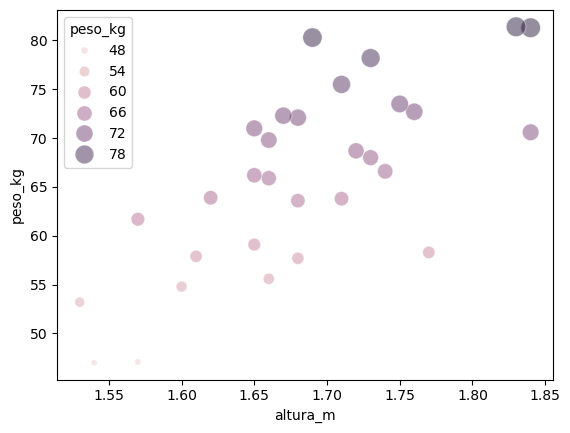

In [26]:
import seaborn as sb
sb.scatterplot(x='altura_m', y='peso_kg', data=data,
               hue='peso_kg', size='peso_kg', sizes=(20, 200), alpha=0.5)

> La gráfica de dispersión muestra la relación positiva entre la altura y el peso de los 30 registros de tu dataset.

## Resumen del Análisis

* Tendencia general: Existe una correlación directa. A mayor altura (eje X), el peso (eje Y) tiende a aumentar de forma lineal.
* Codificación visual: El gráfico utiliza el tamaño y color de las burbujas para reforzar el peso. Los puntos más pequeños y claros representan pesos bajos (cercanos a 48 kg), mientras que los círculos más grandes y oscuros representan los pesos más altos (cercanos a 78-81 kg).
* Distribución:
* Los valores de altura se concentran principalmente entre 1.60 m y 1.75 m.
   * Los valores de peso se agrupan mayoritariamente entre los 55 kg y 75 kg.
* Casos extremos: Se observan dos registros con la altura máxima (cercana a 1.84 m) que también presentan los pesos más altos del grupo (superiores a 80 kg), ubicados en la esquina superior derecha.

# Preparar los datos

In [27]:
# Características (X) y etiquetas (y)
X = data['altura_m']
y = data['peso_kg']

In [28]:
y

0     66.6
1     80.3
2     72.7
3     70.6
4     72.1
5     57.7
6     81.3
7     58.3
8     55.6
9     73.5
10    69.8
11    65.9
12    68.7
13    53.2
14    47.0
15    59.1
16    57.9
17    78.2
18    63.9
19    47.1
20    81.4
21    63.6
22    63.8
23    61.7
24    71.0
25    75.5
26    54.8
27    68.0
28    66.2
29    72.3
Name: peso_kg, dtype: float64

In [29]:
X.values
# Transformando a un array
# [-40, -10, 0, 8, 15, 22, 38]
# [[-40], [-10], [0], [8], [15], [22], [38]]
X_procesada = X.values.reshape(-1, 1)
y_procesada = y.values.reshape(-1, 1)

# Crear nuestro primer modelo

In [30]:
from sklearn.linear_model import LinearRegression
model = LinearRegression()# aplicar en modelo de regresión lineal de sklearn

In [31]:
# Entrenando del modelo
model.fit(X_procesada, y_procesada)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


# Predicción

In [32]:
model.predict([[1.58]])

array([[57.26692739]])

In [33]:
altura = 1.58
prediccion = model.predict([[altura]])
print(f'La altura de {altura} m corresponde a un peso de {prediccion[0][0]} kg')

La altura de 1.58 m corresponde a un peso de 57.266927393896864 kg


In [34]:
altura = 1.61
prediccion = model.predict([[altura]])
print(f'La altura de {altura} m corresponde a un peso de {prediccion[0][0]} kg')

La altura de 1.61 m corresponde a un peso de 59.781045247281654 kg


In [35]:
model.score(X_procesada, y_procesada)

0.5223346755229668